# Multi-linear regression

#### Simple Regression

Simple regression: in which we have two columns input and output and output column is numerical colum.

then we plot x and y and see data relation is linear or sort of linear then we draw best fit line if data is linear or sort of linear. That best fit line is regression line. to draw this line we need equation

y=mx+b

we need to find m and b because y is for example package and x is cgpa.

## Multi Linear Regression

In this we have more than one input(independent )columns and one is output(dependent) column.

It is an extension of simple linear regression

In this plot data in three d if we ahve three column

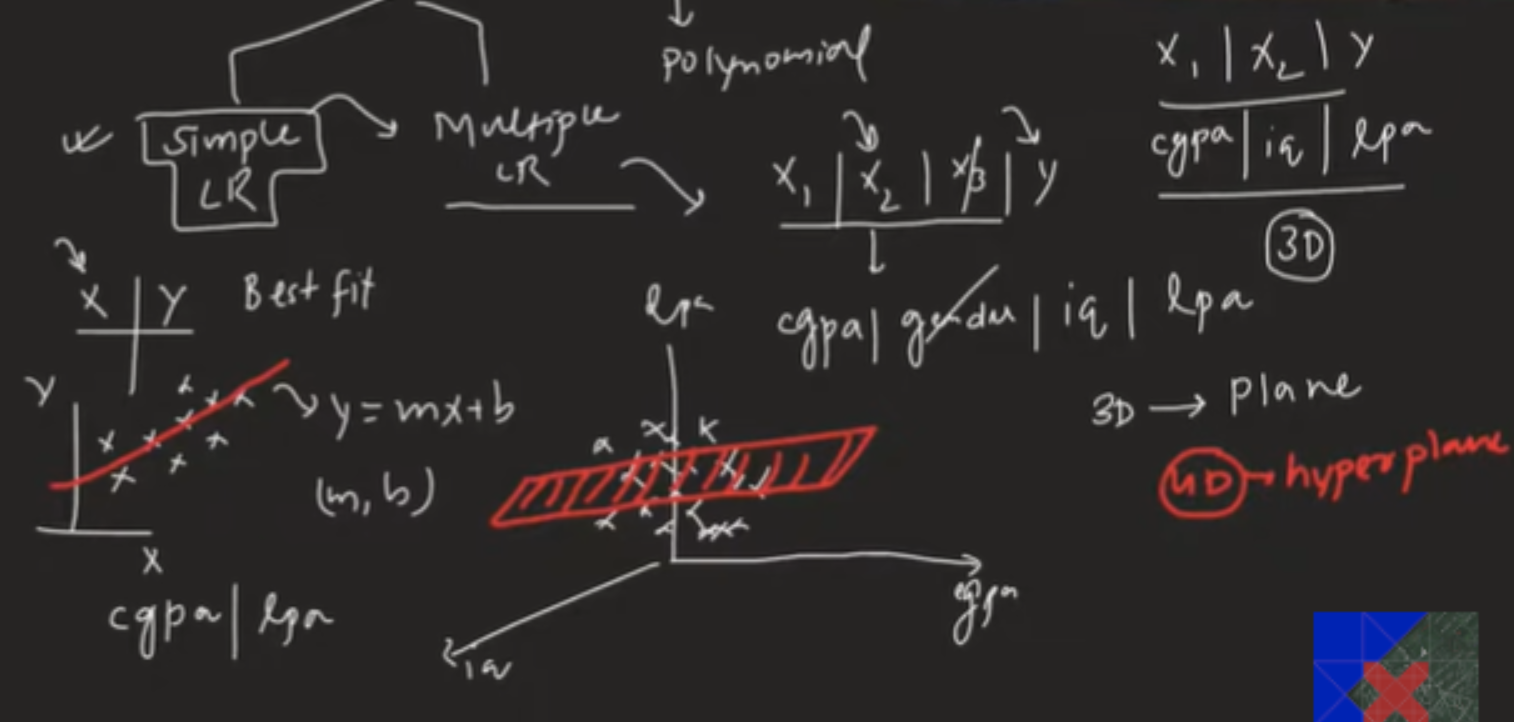

In 2D we draw a best fit line, but in 3D we draw a plane that cuts through the data and lies as close as possible to the data points. For dimensions higher than 3D, we call it a hyperplane.

Our equation now becomes:
- y = mx₁ + nx₂ + b
- or equivalently: y = β₀ + β₁x₁ + β₂x₂

Now we need to find the values of β₀, β₁, and β₂.

Comparing with the previous equation y = mx + b, m becomes β₁ and b becomes β₀

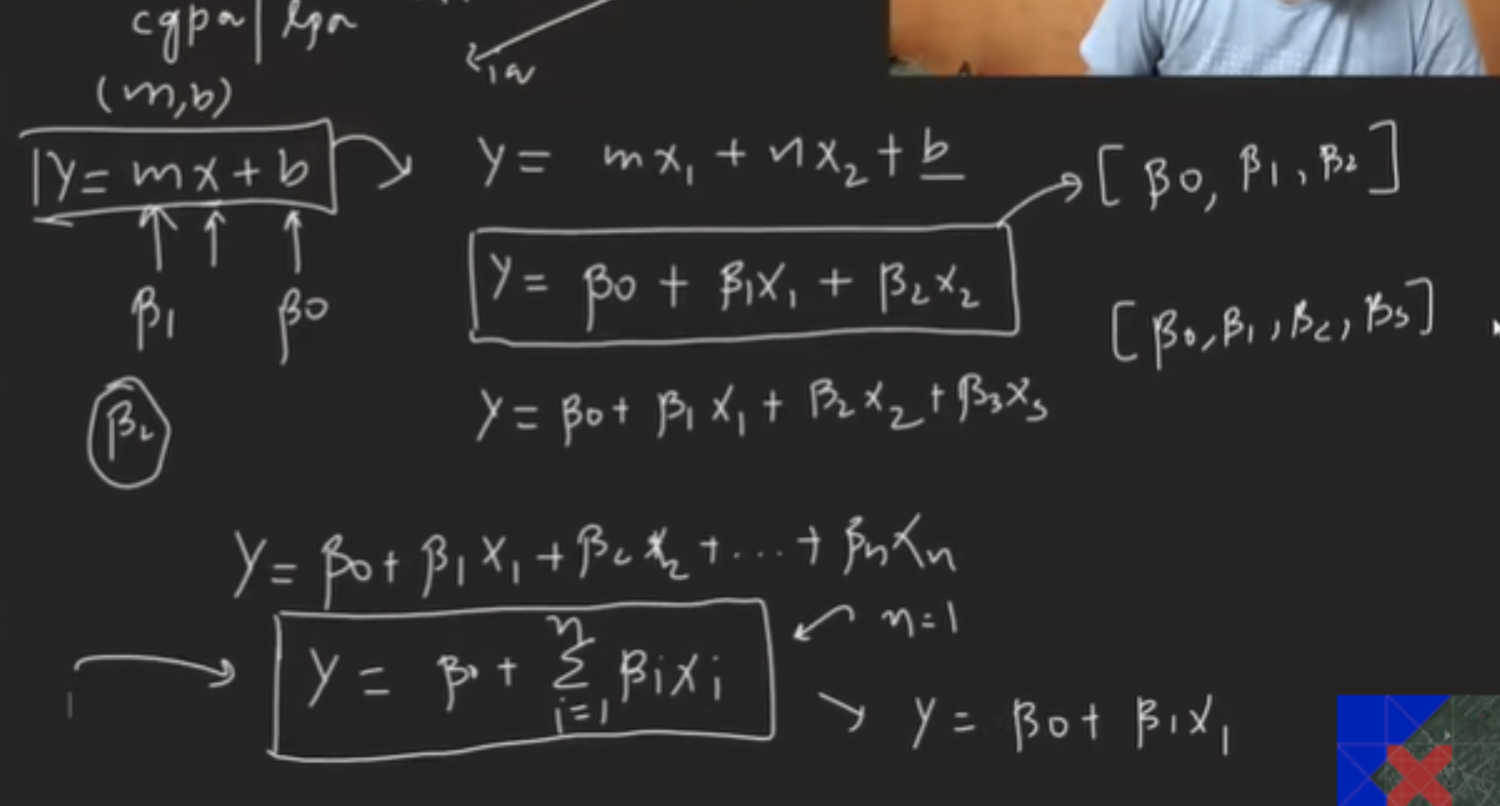

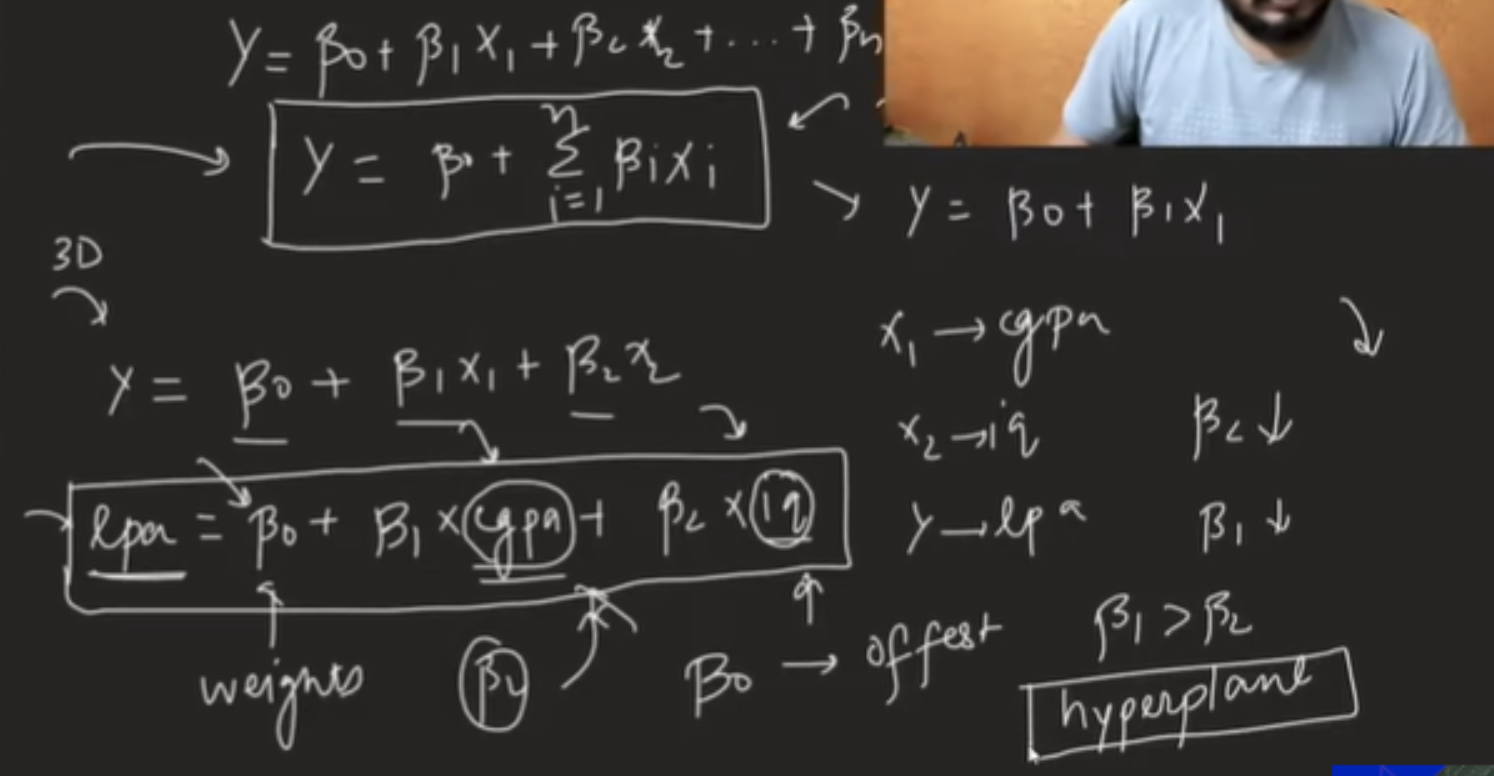

# Code Example

In [4]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [5]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)
     
# with make-regression function we can generate higher dimension linear regression data
# n-sample means 100 rows data
# n-features2,informative, input column and target is output column
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})
     

df.shape

(100, 3)

In [6]:
df.head()

,feature1,feature2,target
0,-0.929480,-1.358079,-227.350889
1,0.197517,1.637430,204.593669
2,-0.317551,-0.313760,-93.339548
3,0.154638,1.008938,139.753752
4,-1.114857,0.049011,-139.488528


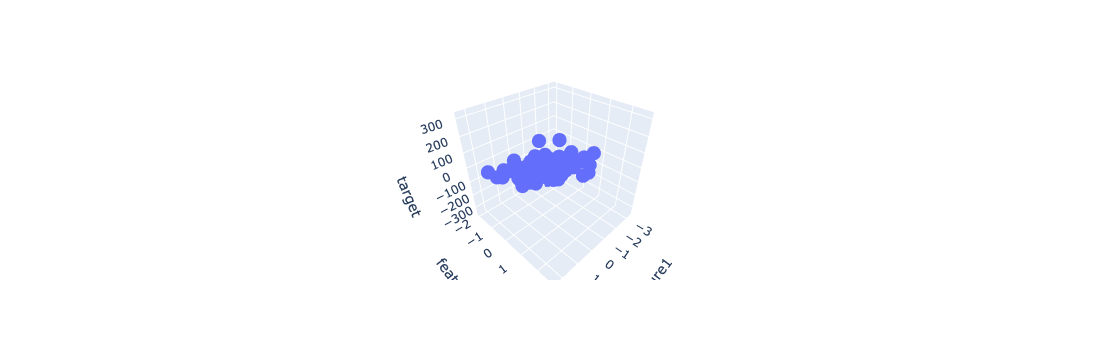

In [7]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)
     

from sklearn.linear_model import LinearRegression
     

lr = LinearRegression()
     

lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = lr.predict(X_test)
     

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 34.4457936799942
MSE 1927.8104412193552
R2 score 0.8874958951711546


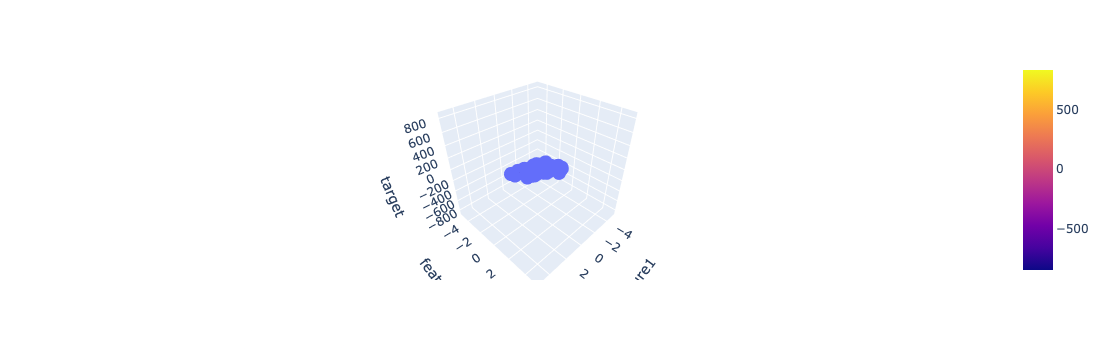

In [10]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(x, y)

# create final FIRST
final = np.vstack((
    xGrid.ravel(),
    yGrid.ravel()
)).T

# now predict
z_final = lr.predict(final).reshape(10, 10)
z = z_final

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(
    go.Surface(x=x, y=y, z=z)
)

fig.show()


In [12]:
lr.coef_ 
# beta1&beta2 value

array([ 63.34674949, 104.26039851])

In [13]:
lr.intercept_ # betanote value 

-7.047067008975689